# 2 – Análisis de ejes biológicos (refinado para la firma del grafo)

Dos niveles de análisis:
1. **Cobertura funcional** de la firma del grafo (estructural)
2. **Scores por muestra** sobre la expresión completa (funcional por subtipo)

In [16]:
import os, sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from breastgnn.config import CFG
from breastgnn.utils import set_seed, set_all_seeds, cleanup_memory
from breastgnn.data import (
    load_expression_and_metadata, prepare_genes, encode_labels,
    cohort_split, scale_features, apply_connected_only,
    make_dataloaders, build_regulator_features, ExpressionDataset,
)
from breastgnn.graph import build_backbone
from breastgnn.graph_cache import get_or_build_backbone, get_or_build_Xh
from breastgnn.losses import compute_metrics_full, compute_class_weights_balanced
from breastgnn.training import predict_proba_xh_mode
from breastgnn.pruning import export_pruned_graph
from breastgnn.ablation import (
    AblationConfig, load_bundle, build_pruned_model_from_bundle,
    register_runtime, get_full_gene_matrix_and_genes,
    run_single_seed, run_ablation,
)

set_seed(CFG.SEED)
DEVICE = CFG.DEVICE
print("DEVICE:", DEVICE)


DEVICE: cuda


In [17]:
from breastgnn.axes import (
    compute_axis_scores, plot_axis_boxplots,
    plot_axis_heatmap_by_subtype, plot_axis_correlation,
    plot_axis_embedding, axis_stats_by_subtype,
    one_vs_rest_axis_analysis, summarize_one_vs_rest,
    plot_one_vs_rest_heatmap, summarize_axis_overlap_with_graph,
)


## 1) Data pipeline

In [18]:
X_df, y_str, cohort = load_expression_and_metadata(
    CFG.EXPR_CSV, CFG.META_CSV,
    sample_col=CFG.SAMPLE_COL, label_col=CFG.LABEL_COL, cohort_col=CFG.COHORT_COL,
)
X_df_kegg, genes_kegg = prepare_genes(X_df)
y, classes, label_map = encode_labels(y_str)
n_classes = len(classes)


X_df: (5812, 11907) | y: (5812,) | cohort: (5812,)
Targets:
 LumA      2514
LumB      1202
TNBC      1026
HER2       602
Normal     468
Name: count, dtype: int64
Genes totales (nodos): 11907
y: (5812,), n_classes: 5, classes: ['HER2', 'LumA', 'LumB', 'Normal', 'TNBC']


In [19]:
edge_index, edge_weight, edge_type = get_or_build_backbone(
    genes_kegg, cache_dir=CFG.PIPELINE_CACHE_DIR,
    force_rebuild=False, use_omnipath=CFG.USE_OMNIPATH, use_huri=CFG.USE_HURI,
)
print(f"Backbone: {edge_index.shape[1]} aristas, {len(genes_kegg)} genes")


[graph_cache] Intentando cargar backbone: backbone__362de41006ca05c1__e71ae7463734.npz
[graph_cache] Backbone válido desde caché: 51445 aristas, 11907 genes
Backbone: 51445 aristas, 11907 genes


In [20]:
train_idx, val_idx, test_idx = cohort_split(
    cohort, y, train_cohort_frac=0.80, val_size=CFG.VAL_SIZE, seed=CFG.SEED,
)
Xs_gene = scale_features(X_df_kegg, train_idx, mode=CFG.SCALE_MODE, use_quantile=CFG.USE_QUANTILE)

if CFG.CONNECTED_ONLY:
    Xs_gene, edge_index, edge_weight, edge_type, genes_kegg = apply_connected_only(
        Xs_gene, edge_index, edge_weight, edge_type, genes_kegg,
    )


Total cohorts: 12
Split sizes: train=3805, val=952, test=1055
Cohorts TRAIN: ['GSE1456', 'GSE15852', 'GSE162228', 'GSE19615', 'GSE20711', 'GSE21653', 'GSE25066', 'GSE65194', 'GSE96058']
Cohorts TEST: ['GSE32646', 'GSE58812', 'TCGA']
[CONNECTED_ONLY] 11907 -> 7213 genes, 51445 -> 51445 edges


In [21]:
Xs_graph, graph_feat_names = get_or_build_Xh(
    Xs_gene, genes_kegg, edge_index,
    cache_dir=CFG.PIPELINE_CACHE_DIR,
    stats=CFG.REG_STATS, min_targets=CFG.REG_MIN_GENES,
    max_regulators=CFG.REG_MAX_REGULATORS,
)


[graph_cache] Cargando Xs_graph (X_h) desde caché: Xh__0575558be8d8a450__c102b7893b38__2060915c8ab9.npz
[graph_cache]   → Xs_graph shape: (5812, 7611)


In [22]:
dl_tr, dl_va, dl_te = make_dataloaders(
    Xs_gene, Xs_graph, y, train_idx, val_idx, test_idx, batch_size=CFG.BATCH_SIZE,
)


Batches train/val/test: 191/48/53


In [23]:
edge_index_t = torch.as_tensor(edge_index, dtype=torch.long, device=DEVICE)
edge_weight_t = torch.as_tensor(edge_weight, dtype=torch.float32, device=DEVICE)
edge_type_t = torch.as_tensor(edge_type, dtype=torch.long, device=DEVICE)

register_runtime(
    Xs_gene=Xs_gene, genes_kegg=genes_kegg, X_h=Xs_graph,
    y=y, n_classes=n_classes, label_map=label_map,
    train_idx=train_idx, val_idx=val_idx, test_idx=test_idx,
    edge_index_t=edge_index_t, edge_weight_t=edge_weight_t, edge_type_t=edge_type_t,
)


## 2) Definir ejes biológicos

In [24]:
AXES = {
    "Luminal Hormonal": [
        "ESR1","PGR","GATA3","GREB1","ESR2","PHLDA1","LRIG1","RXRA"
    ],
    "Cell Cycle Mitotic": [
        "AURKA","AURKB","BUB1","CDC7","CDC23","CDCA3","CDK1","CDK2",
        "CEP55","E2F1","FOXM1","PLK1","TTK","ZWINT"
    ],
    "HER2 RTK MAPK": [
        "ERBB2","EGFR","IGF1R","MET","PDGFRB","AKT1","MAP2K1","MAP2K2",
        "MAPK1","MAPK3","MAPK14","PLCG1","SRC","LYN"
    ],
    "Basal Plasticity TNBC": [
        "KRT6A","KRT16","SOX10","VGLL1","VGLL3","EGFR","EMP1","MSLN"
    ],
    "Immune Lymphoid Signaling": [
        "CD79A","CXCL9","DEF6","GRAP2","HCK","JAK3","ITPKB","PAX5",
        "SYK","S1PR1","SOCS1","TRAF1","TRAF2","ZBP1"
    ],
    "DNA Damage p53 Checkpoint": [
        "ATM","ERCC3","FANCG","KAT5","PRKDC","TP53","MDM2","PTEN",
        "DAPK1","STK11","SIRT1"
    ],
    "Adhesion Cytoskeleton Invasion": [
        "ABI2","FLNA","ITGB1","ITGB1BP1","MMP2","PTK2","RHOA","ROCK1",
        "LASP1","NCK1","NCK2","SDCBP"
    ],
    "Androgen Apocrine": [
        "AR","MSLN"
    ],
}
AXES_ORDER = list(AXES.keys())


## 3) Cobertura de ejes en la firma del grafo

In [25]:
# Genes del grafo conectado
graph_genes = set(g.upper() for g in genes_kegg)
overlap_df = summarize_axis_overlap_with_graph(graph_genes, AXES)
display(overlap_df)


,Axis,Axis_pretty,n_axis_genes,n_in_graph,coverage_in_graph,present_in_graph,missing_from_graph
0,Cell Cycle Mitotic,Cell Cycle Mitotic,14,14,1.0,"AURKA, AURKB, BUB1, CDC7, CDC23, CDCA3, CDK1, ...",
1,HER2 RTK MAPK,HER2 RTK MAPK,14,14,1.0,"ERBB2, EGFR, IGF1R, MET, PDGFRB, AKT1, MAP2K1,...",
2,Immune Lymphoid Signaling,Immune Lymphoid Signaling,14,14,1.0,"CD79A, CXCL9, DEF6, GRAP2, HCK, JAK3, ITPKB, P...",
3,Adhesion Cytoskeleton Invasion,Adhesion Cytoskeleton Invasion,12,12,1.0,"ABI2, FLNA, ITGB1, ITGB1BP1, MMP2, PTK2, RHOA,...",
4,DNA Damage p53 Checkpoint,DNA Damage p53 Checkpoint,11,11,1.0,"ATM, ERCC3, FANCG, KAT5, PRKDC, TP53, MDM2, PT...",
5,Basal Plasticity TNBC,Basal Plasticity TNBC,8,8,1.0,"KRT6A, KRT16, SOX10, VGLL1, VGLL3, EGFR, EMP1,...",
6,Luminal Hormonal,Luminal Hormonal,8,8,1.0,"ESR1, PGR, GATA3, GREB1, ESR2, PHLDA1, LRIG1, ...",
7,Androgen Apocrine,Androgen Apocrine,2,2,1.0,"AR, MSLN",


## 4) Scores por muestra (expresión completa)

In [26]:
df_expr_raw = pd.read_csv(CFG.EXPR_CSV, index_col=0)
metadata_axes = pd.read_csv(CFG.META_CSV, index_col=0)[["sample", "batch", "label"]]

meta_scores, axis_info, Xz = compute_axis_scores(
    expr_df=df_expr_raw, meta_df=metadata_axes,
    axes=AXES, sample_col="sample", label_col="label",
)
display(axis_info[["Axis", "n_present", "coverage", "present_genes"]])


Orientación detectada: genes_x_samples -> transposed
Muestras usadas: 5812
Genes en expresión (tras dedup): 11907


,Axis,n_present,coverage,present_genes
0,Cell Cycle Mitotic,14,1.0,"AURKA, AURKB, BUB1, CDC7, CDC23, CDCA3, CDK1, ..."
1,HER2 RTK MAPK,14,1.0,"ERBB2, EGFR, IGF1R, MET, PDGFRB, AKT1, MAP2K1,..."
2,Immune Lymphoid Signaling,14,1.0,"CD79A, CXCL9, DEF6, GRAP2, HCK, JAK3, ITPKB, P..."
3,Adhesion Cytoskeleton Invasion,12,1.0,"ABI2, FLNA, ITGB1, ITGB1BP1, MMP2, PTK2, RHOA,..."
4,DNA Damage p53 Checkpoint,11,1.0,"ATM, ERCC3, FANCG, KAT5, PRKDC, TP53, MDM2, PT..."
5,Luminal Hormonal,8,1.0,"ESR1, PGR, GATA3, GREB1, ESR2, PHLDA1, LRIG1, ..."
6,Basal Plasticity TNBC,8,1.0,"KRT6A, KRT16, SOX10, VGLL1, VGLL3, EGFR, EMP1,..."
7,Androgen Apocrine,2,1.0,"AR, MSLN"


## 5) Figuras

In [12]:
SAVE = "./figures_axes_refined"

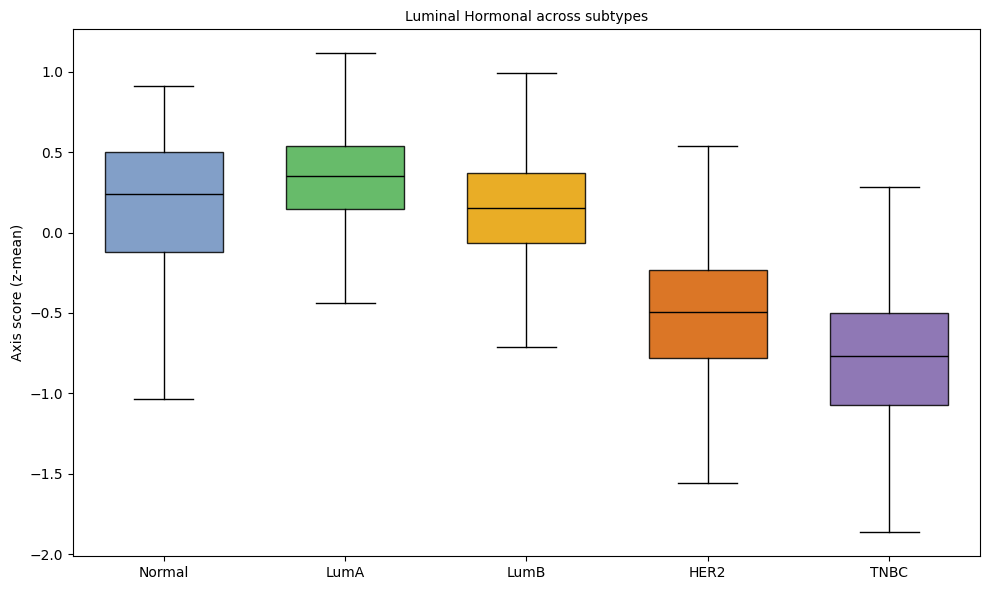

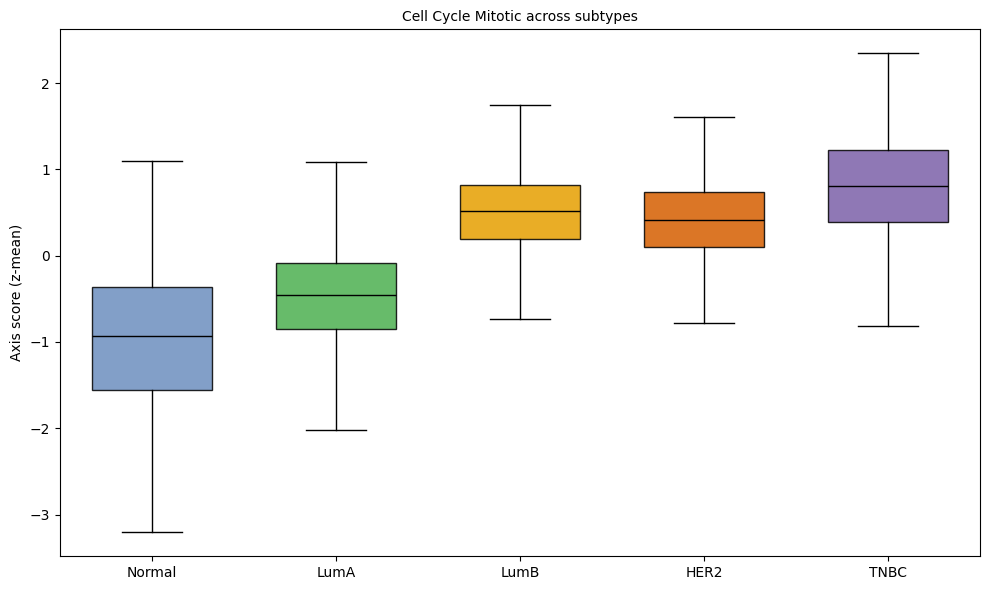

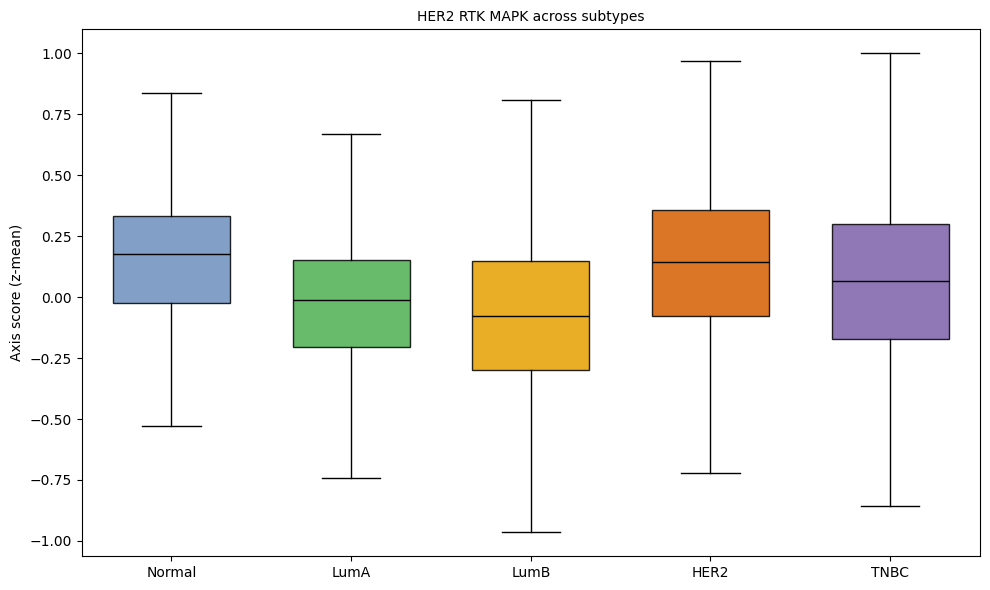

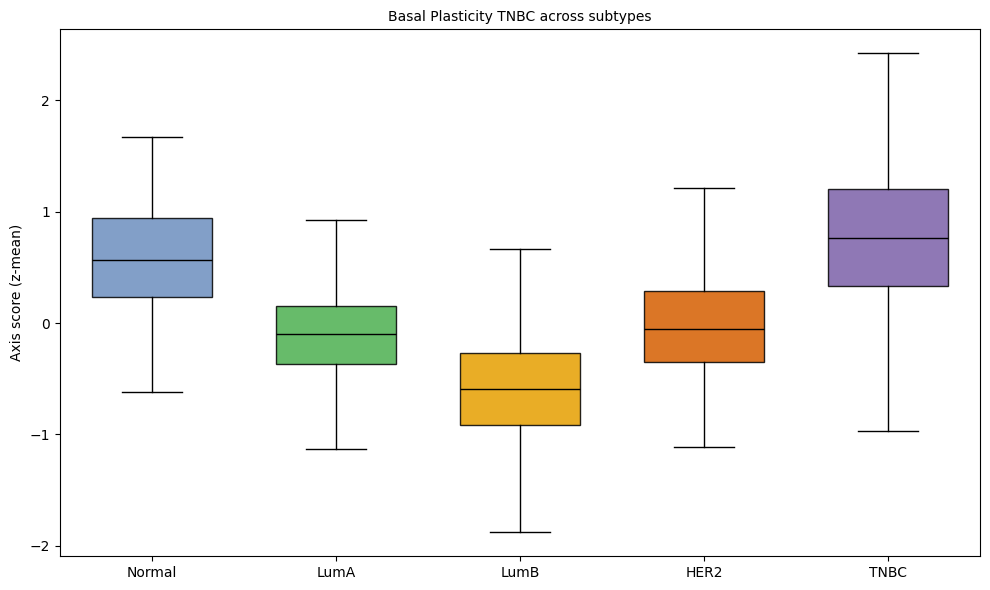

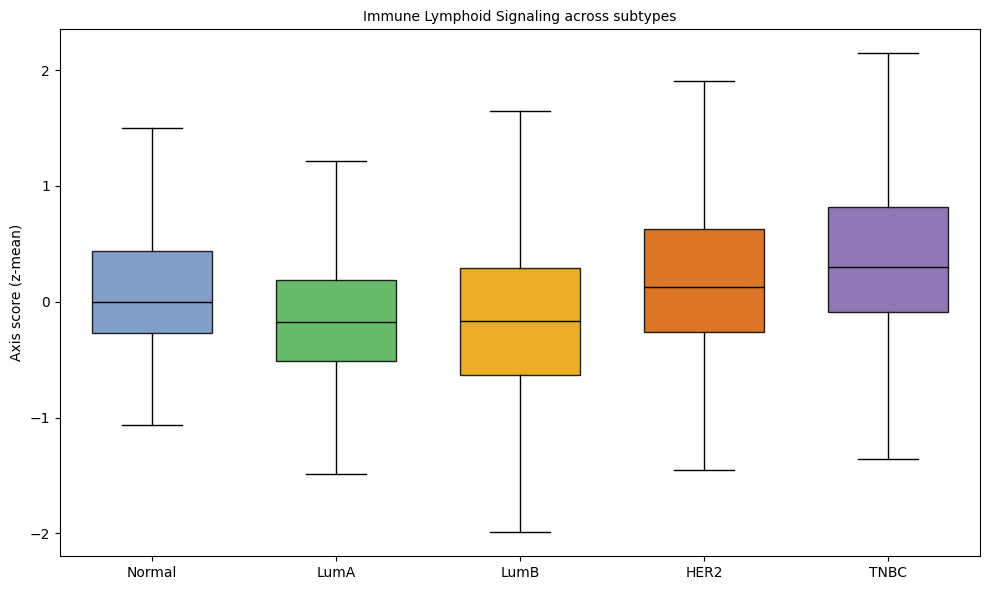

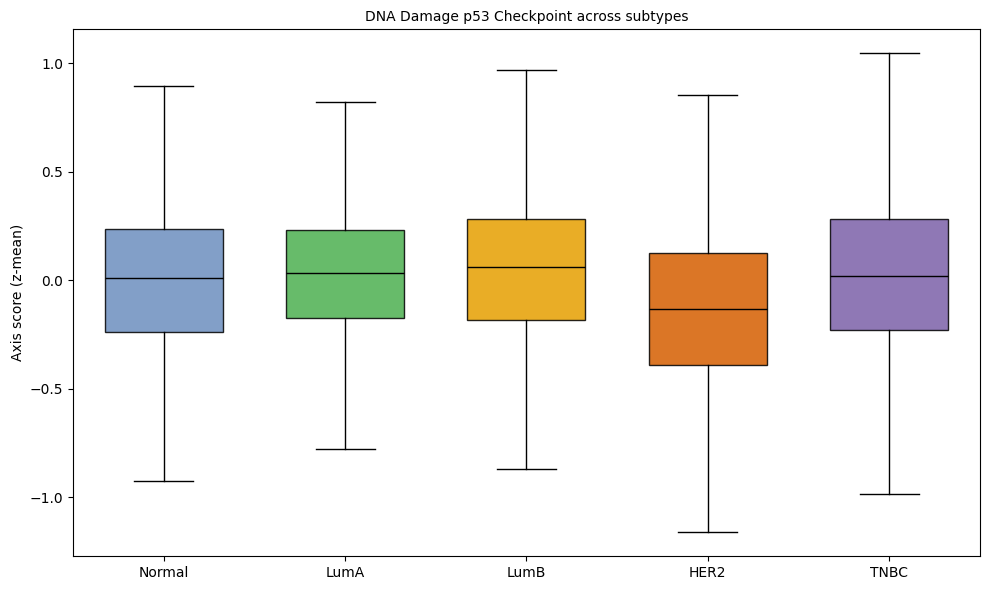

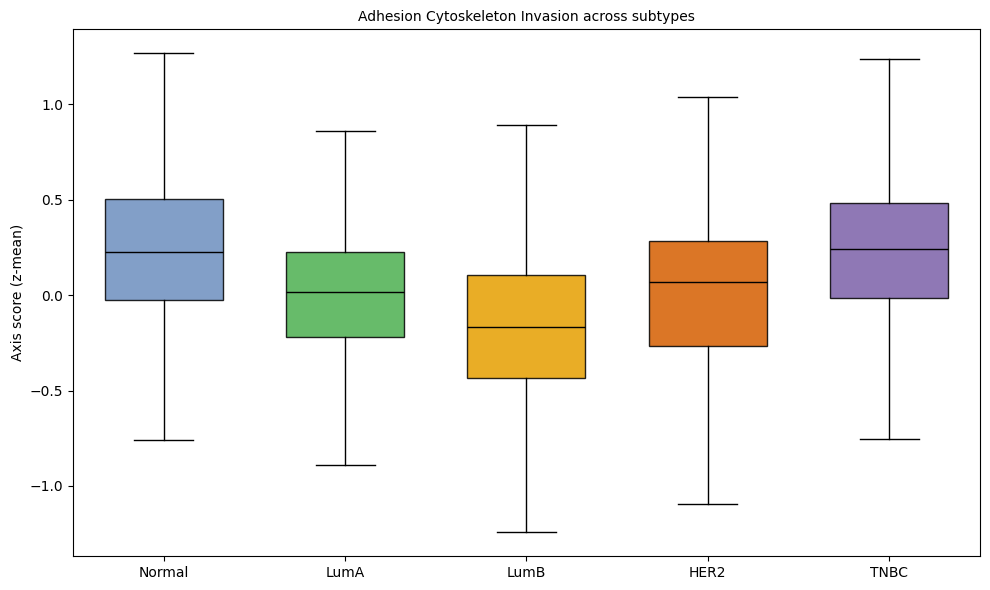

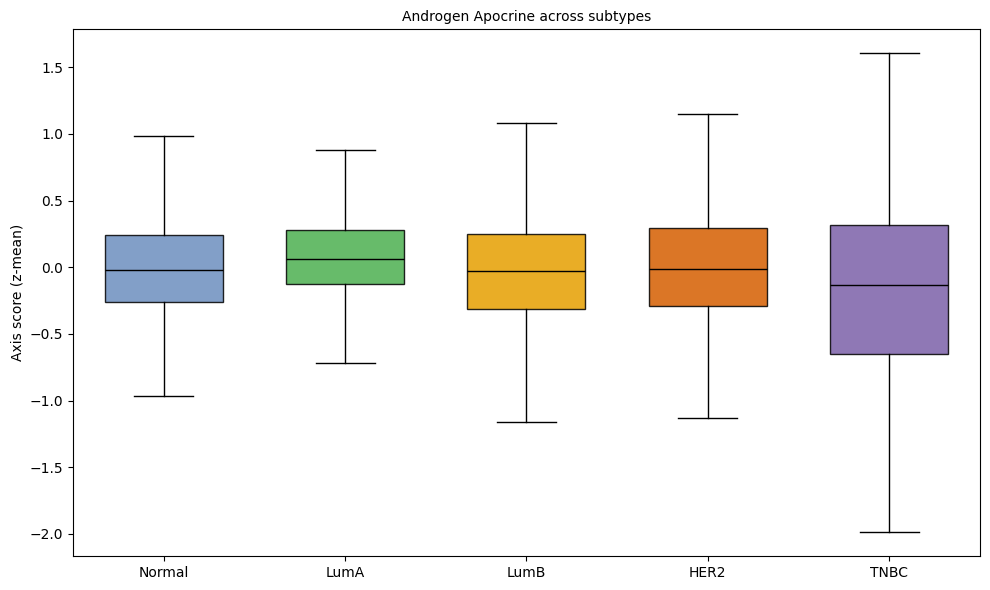

Figure saved to: /home/alejandro/Escritorio/Trabajo/Laura_Senovilla/Grafo_TNBC/breastgnn_package/notebooks/figures_axes_refined/mean_axis_scores_by_subtype.svg


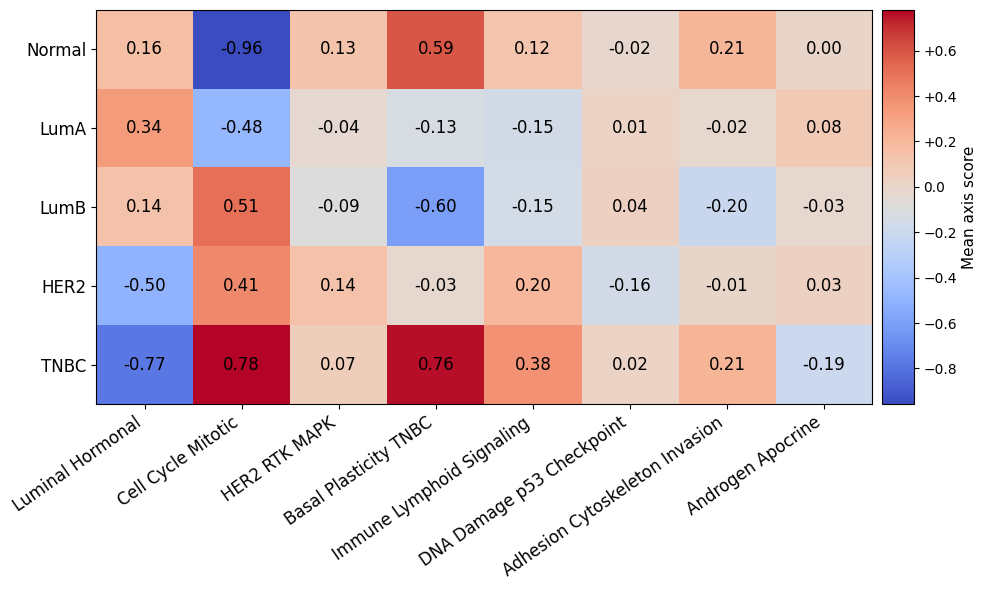

,Luminal Hormonal,Cell Cycle Mitotic,HER2 RTK MAPK,Basal Plasticity TNBC,Immune Lymphoid Signaling,DNA Damage p53 Checkpoint,Adhesion Cytoskeleton Invasion,Androgen Apocrine
label,,,,,,,,
Normal,0.159067,-0.956158,0.129159,0.592832,0.116887,-0.020067,0.205229,0.001819
LumA,0.338150,-0.481061,-0.039471,-0.126465,-0.153632,0.014999,-0.024860,0.083630
LumB,0.140645,0.508015,-0.091295,-0.604219,-0.146686,0.039922,-0.203841,-0.026521
HER2,-0.497649,0.409765,0.135789,-0.026923,0.200683,-0.155226,-0.006880,0.030145
TNBC,-0.773902,0.779296,0.065084,0.763127,0.377226,0.016710,0.210145,-0.192364


Figure saved to: /home/alejandro/Escritorio/Trabajo/Laura_Senovilla/Grafo_TNBC/breastgnn_package/notebooks/figures_axes_refined/correlacion_spearman_ejes.svg


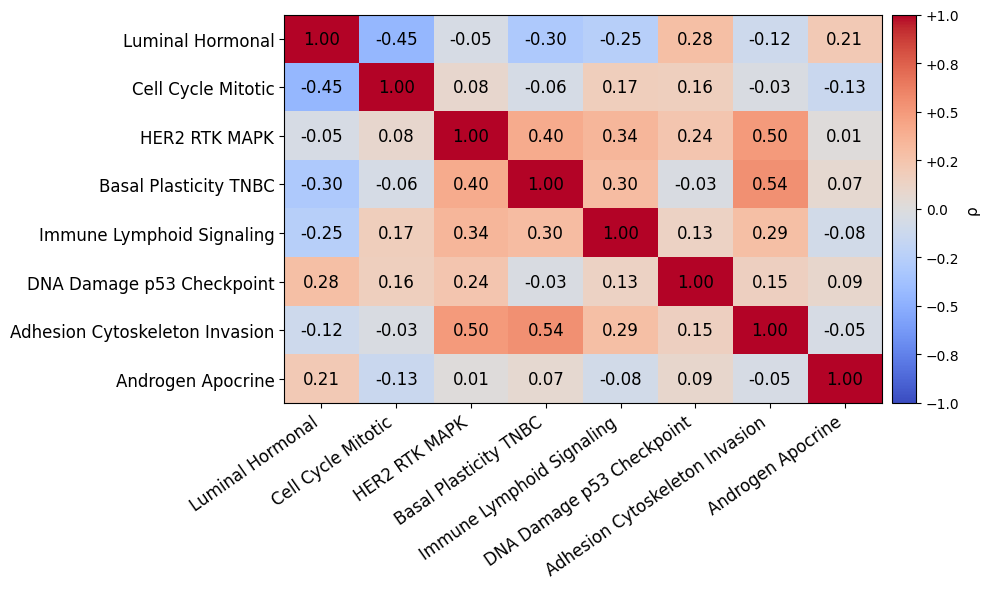

,Luminal Hormonal,Cell Cycle Mitotic,HER2 RTK MAPK,Basal Plasticity TNBC,Immune Lymphoid Signaling,DNA Damage p53 Checkpoint,Adhesion Cytoskeleton Invasion,Androgen Apocrine
Luminal Hormonal,1.000000,-0.450382,-0.053581,-0.304812,-0.253536,0.282852,-0.116573,0.210541
Cell Cycle Mitotic,-0.450382,1.000000,0.082964,-0.058034,0.167000,0.163544,-0.032269,-0.134339
HER2 RTK MAPK,-0.053581,0.082964,1.000000,0.400797,0.341884,0.238761,0.499970,0.008609
Basal Plasticity TNBC,-0.304812,-0.058034,0.400797,1.000000,0.297965,-0.033868,0.542252,0.068108
Immune Lymphoid Signaling,-0.253536,0.167000,0.341884,0.297965,1.000000,0.129036,0.286765,-0.082712
DNA Damage p53 Checkpoint,0.282852,0.163544,0.238761,-0.033868,0.129036,1.000000,0.154544,0.091087
Adhesion Cytoskeleton Invasion,-0.116573,-0.032269,0.499970,0.542252,0.286765,0.154544,1.000000,-0.049021
Androgen Apocrine,0.210541,-0.134339,0.008609,0.068108,-0.082712,0.091087,-0.049021,1.000000


Figure saved to: /home/alejandro/Escritorio/Trabajo/Laura_Senovilla/Grafo_TNBC/breastgnn_package/notebooks/figures_axes_refined/pca_axes_space.svg


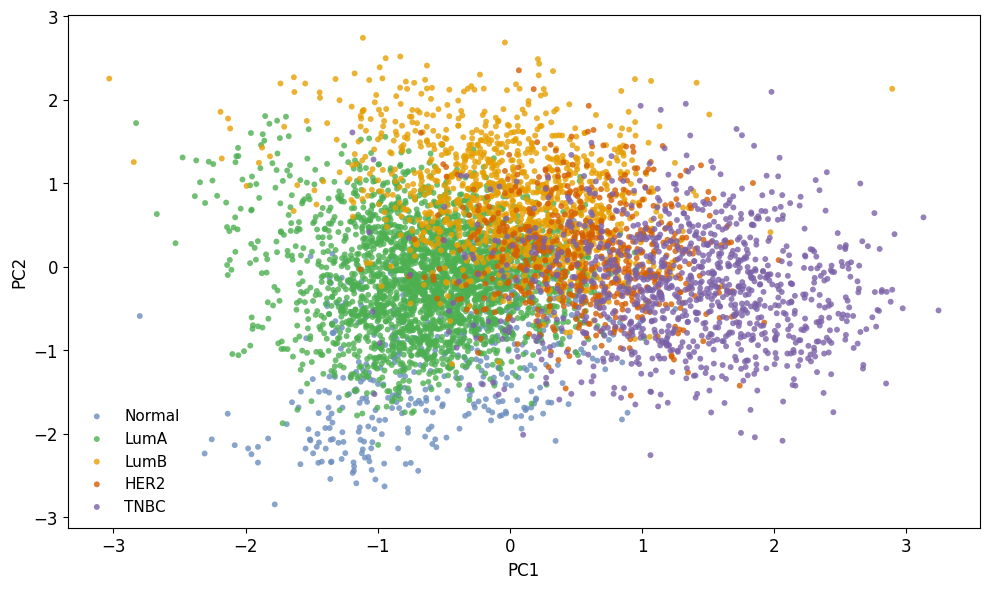

/home/alejandro/.pyenv/versions/3.14.3/envs/Torch/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/alejandro/.pyenv/versions/3.14.3/envs/Torch/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Figure saved to: /home/alejandro/Escritorio/Trabajo/Laura_Senovilla/Grafo_TNBC/breastgnn_package/notebooks/figures_axes_refined/umap_axes_space.svg


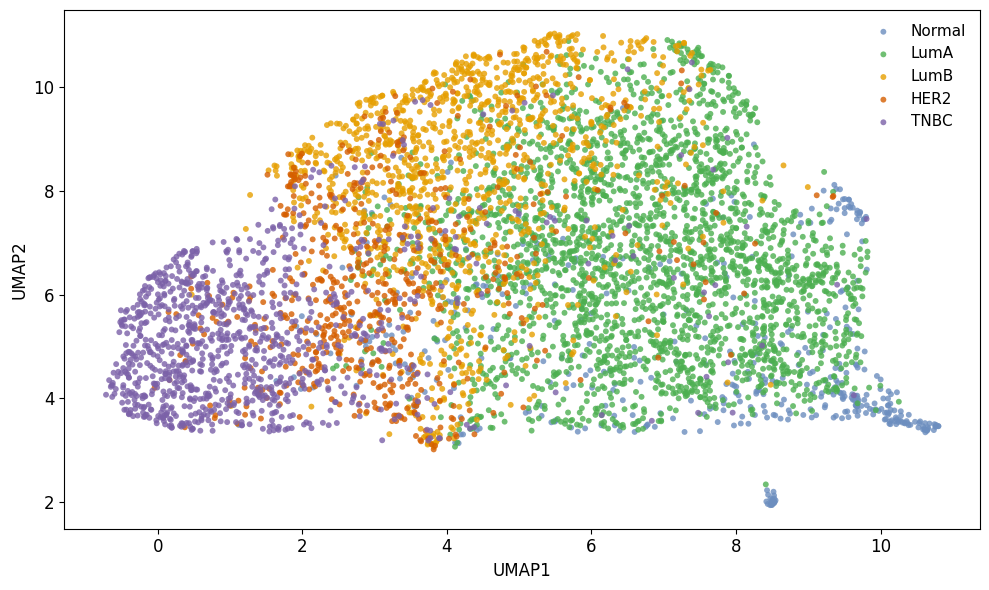

,Axis,Axis_pretty,Kruskal_H,p_value,p_fdr
0,Luminal Hormonal,Luminal Hormonal,3124.975065,0.000000e+00,0.000000e+00
1,Cell Cycle Mitotic,Cell Cycle Mitotic,3134.372728,0.000000e+00,0.000000e+00
2,Basal Plasticity TNBC,Basal Plasticity TNBC,2671.647035,0.000000e+00,0.000000e+00
3,Adhesion Cytoskeleton Invasion,Adhesion Cytoskeleton Invasion,633.678400,7.955936e-136,1.591187e-135
4,Immune Lymphoid Signaling,Immune Lymphoid Signaling,568.246302,1.153229e-121,1.845167e-121
5,HER2 RTK MAPK,HER2 RTK MAPK,337.672575,8.041972e-72,1.072263e-71
6,Androgen Apocrine,Androgen Apocrine,158.256933,3.457247e-33,3.951140e-33
7,DNA Damage p53 Checkpoint,DNA Damage p53 Checkpoint,115.615876,4.610707e-24,4.610707e-24


In [13]:
plot_axis_boxplots(meta_scores, label_col="label")
heat = plot_axis_heatmap_by_subtype(meta_scores, dpi=300,title="", title_fontsize=16, tick_fontsize=12, annot_fontsize=12,label_col="label",save_dir=SAVE)
display(heat)
corr=plot_axis_correlation(meta_scores, dpi=300, title="", title_fontsize=16, tick_fontsize=12, annot_fontsize=12,save_dir=SAVE)
display(corr)
plot_axis_embedding(meta_scores,dpi=300, label_col="label",pca_title="", umap_title="", tick_fontsize=12, axis_label_fontsize=12,save_dir=SAVE)
stats_df = axis_stats_by_subtype(meta_scores, label_col="label")
display(stats_df)


## 6) One-vs-rest por subtipo

,Subtype,Axis,Axis_pretty,n_subtype,n_rest,mean_subtype,mean_rest,delta_mean,median_subtype,median_rest,delta_median,U,p_value,rank_biserial,AUC_effect,cohen_d,direction,p_fdr_global,p_fdr_subtype
0,HER2,Luminal Hormonal,Luminal Hormonal,602,5210,-0.497649,0.057502,-0.555151,-0.493629,0.186466,-0.680094,604849.0,7.361947e-135,-0.614306,0.192847,-1.051221,down_in_subtype,3.680973e-134,5.889557e-134
1,HER2,Cell Cycle Mitotic,Cell Cycle Mitotic,602,5210,0.409765,-0.047347,0.457112,0.415469,-0.044744,0.460214,2110354.0,5.606280e-44,0.345709,0.672854,0.556728,up_in_subtype,1.495008e-43,2.242512e-43
2,HER2,HER2 RTK MAPK,HER2 RTK MAPK,602,5210,0.135789,-0.015690,0.151479,0.143334,0.003523,0.139811,1980128.0,4.203448e-26,0.262668,0.631334,0.452017,up_in_subtype,9.890466e-26,1.120920e-25
3,HER2,DNA Damage p53 Checkpoint,DNA Damage p53 Checkpoint,602,5210,-0.155226,0.017936,-0.173161,-0.131874,0.033090,-0.164964,1163735.0,3.161131e-25,-0.257921,0.371039,-0.462696,down_in_subtype,6.655012e-25,6.322262e-25
4,HER2,Immune Lymphoid Signaling,Immune Lymphoid Signaling,602,5210,0.200683,-0.023188,0.223871,0.125470,-0.069204,0.194674,1866654.0,1.909327e-14,0.190309,0.595154,0.338191,up_in_subtype,2.937426e-14,3.054923e-14
5,HER2,Androgen Apocrine,Androgen Apocrine,602,5210,0.030145,-0.003483,0.033628,-0.015347,0.017596,-0.032943,1536289.0,4.128304e-01,-0.020355,0.489822,0.066213,up_in_subtype,4.463031e-01,5.504405e-01
6,HER2,Basal Plasticity TNBC,Basal Plasticity TNBC,602,5210,-0.026923,0.003111,-0.030034,-0.051258,-0.046069,-0.005190,1561907.0,8.715491e-01,-0.004019,0.497990,-0.044893,down_in_subtype,8.938965e-01,9.290737e-01
7,HER2,Adhesion Cytoskeleton Invasion,Adhesion Cytoskeleton Invasion,602,5210,-0.006880,0.000795,-0.007675,0.068628,0.037092,0.031536,1564740.0,9.290737e-01,-0.002213,0.498894,-0.017519,down_in_subtype,9.290737e-01,9.290737e-01
8,LumA,Cell Cycle Mitotic,Cell Cycle Mitotic,2514,3298,-0.481061,0.366703,-0.847764,-0.454098,0.480195,-0.934293,1423419.0,0.000000e+00,-0.656642,0.171679,-1.178936,down_in_subtype,0.000000e+00,0.000000e+00
9,LumA,Luminal Hormonal,Luminal Hormonal,2514,3298,0.338150,-0.257765,0.595915,0.353716,-0.206382,0.560098,6742980.0,0.000000e+00,0.626544,0.813272,1.269563,up_in_subtype,0.000000e+00,0.000000e+00


,Subtype,Top_up_axes,Top_down_axes
0,HER2,"Cell Cycle Mitotic (Δ mean=+0.457, rb=+0.346) ...","Luminal Hormonal (Δ mean=-0.555, rb=-0.614) | ..."
1,LumA,"Luminal Hormonal (Δ mean=+0.596, rb=+0.627) | ...","Cell Cycle Mitotic (Δ mean=-0.848, rb=-0.657) ..."
2,LumB,"Cell Cycle Mitotic (Δ mean=+0.640, rb=+0.484) ...","Basal Plasticity TNBC (Δ mean=-0.762, rb=-0.68..."
3,Normal,"Basal Plasticity TNBC (Δ mean=+0.645, rb=+0.60...","Cell Cycle Mitotic (Δ mean=-1.040, rb=-0.629) ..."
4,TNBC,"Cell Cycle Mitotic (Δ mean=+0.946, rb=+0.662) ...","Luminal Hormonal (Δ mean=-0.940, rb=-0.867) | ..."


Figure saved to: /home/alejandro/Escritorio/Trabajo/Laura_Senovilla/Grafo_TNBC/breastgnn_package/notebooks/figures_axes_refined/one_vs_rest_heatmap.svg


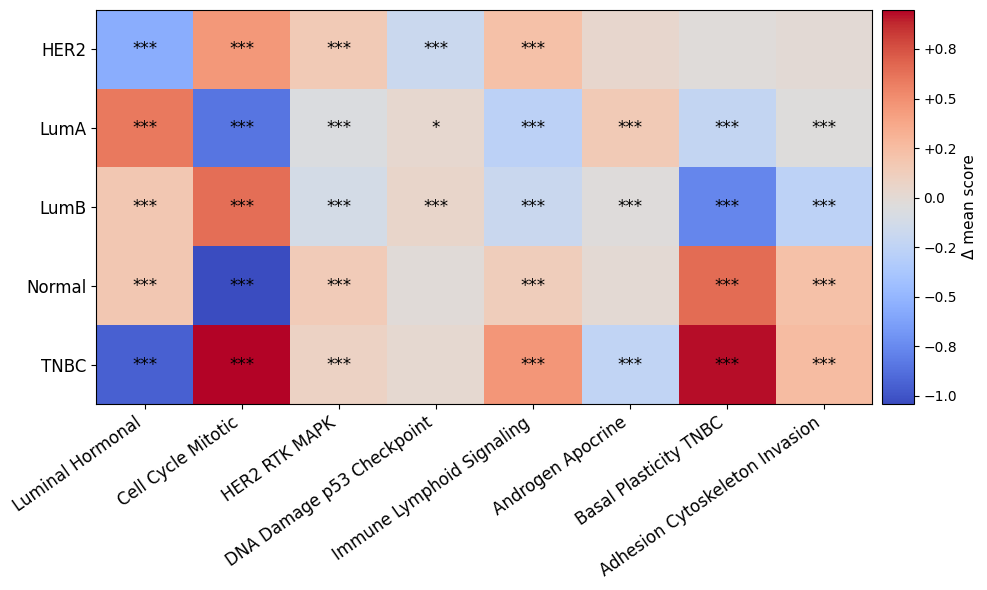

(Axis     Luminal Hormonal  Cell Cycle Mitotic  HER2 RTK MAPK  \
 Subtype                                                        
 HER2            -0.555151            0.457112       0.151479   
 LumA             0.595915           -0.847764      -0.069560   
 LumB             0.177316            0.640473      -0.115099   
 Normal           0.172998           -1.039894       0.140470   
 TNBC            -0.939807            0.946357       0.079037   
 
 Axis     DNA Damage p53 Checkpoint  Immune Lymphoid Signaling  \
 Subtype                                                         
 HER2                     -0.173161                   0.223871   
 LumA                      0.026432                  -0.270743   
 LumB                      0.050331                  -0.184932   
 Normal                   -0.021825                   0.127123   
 TNBC                      0.020292                   0.458094   
 
 Axis     Androgen Apocrine  Basal Plasticity TNBC  \
 Subtype                 

In [14]:
ovr_df = one_vs_rest_axis_analysis(meta_scores, label_col="label", axes_order=AXES_ORDER)
display(ovr_df.head(20))

ovr_summary = summarize_one_vs_rest(ovr_df, top_n=3, sort_by="delta_mean")
display(ovr_summary)

plot_one_vs_rest_heatmap(ovr_df, title="", dpi=300,value_col="delta_mean", fdr_col="p_fdr_subtype", tick_fontsize=12, annot_fontsize=12,save_dir=SAVE)


NameError: name 'g' is not defined

# Fin